# 06 — Hyperparameter and family multiplicity (Section 5.7)

**Purpose:** This notebook supports thesis Section 5.7. It analyzes family-level variance decomposition, within-family hyperparameter drivers, hotspot-specific hyperparameter shifts, and a compact Rashomon-vs-full-pool meta-model diagnostic.

**Pipeline:** Collect multi-seed model/HP tables → aggregate family and HP importance → export compact thesis-facing tables → generate Section 5.7 figures and diagnostics.

The notebook intentionally saves only compact CSV summaries and thesis-facing figures. Detailed per-family/per-seed debug exports were removed to keep `thesis_outputs/tables/nb06/` manageable.

## Imports and path setup


In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.hp_analysis import POOL_TYPE_RASHOMON

from analysis.hp_section57 import (
    HPAnalysisConfig,
    aggregate_hp_seed_tables,
    collect_multiseed_hp_tables,
    export_seed_aggregates_and_hotspot_delta
)

from analysis.hp_multiplicity_pipeline import (
    plot_decomp_hp_grid_rashomon,
    plot_family_importance_bars,
    plot_hotspot_hp_delta_grid,
    plot_family_importance_compare_bars
)

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb06")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## Configuration (Section 5.7)

All tunables live in ``HPAnalysisConfig``. Notebook aliases below keep downstream cells readable.


In [2]:
cfg = HPAnalysisConfig(
    results_dir=RESULTS_DIR,
    table_dir=TABLE_DIR,
    fig_dir=FIG_DIR,
)

# Backwards-compatible names for later cells
DATASETS = list(cfg.datasets)
POOL_TYPES = list(cfg.pool_types)
K_EACH = cfg.rashomon_k_each
TOP_HP = cfg.top_hp
MIN_HH_OBS = cfg.min_hh_obs
ILLUSTRATE_SEED = cfg.illustrate_seed


## Stage 1 — Collect multi-seed model and HP tables

Build the in-memory tables used by the rest of the notebook:

- `df_models`: candidate-model metadata across datasets/seeds
- `df_metrics_long`: long-format per-model disagreement metrics
- `df_decomp_hp`: decomposition-based HP tables
- `df_vm_hp`: V_m-based HP tables

These tables are kept in memory for aggregation and plotting. Raw per-dataset debug CSV exports are intentionally not written.

In [3]:
_tables = collect_multiseed_hp_tables(cfg)
df_models = _tables["models"]
df_metrics_long = _tables["metrics_long"]
df_decomp_hp = _tables["decomp_hp_wide"]
df_vm_hp = _tables["vm_hp_wide"]

print("Rows:", {k: len(v) for k, v in [
    ("models", df_models),
    ("metrics_long", df_metrics_long),
    ("decomp_hp", df_decomp_hp),
    ("vm_hp", df_vm_hp),
]})


Rows: {'models': 11250, 'metrics_long': 6386, 'decomp_hp': 3027, 'vm_hp': 3021}


## Stages 2–3: Aggregate V_m and family importance across seeds

Compute per-family V_m importance (via updated grouping) and family-level variance decomposition, aggregating means and standard deviations across seeds. Seed coverage is retained in the aggregate tables where relevant.

In [4]:
_aggs = aggregate_hp_seed_tables(df_metrics_long, df_decomp_hp, df_vm_hp)
df_fam_agg = _aggs["fam_agg"]
df_decomp_agg = _aggs["decomp_agg"]
df_vm_agg = _aggs["vm_agg"]
delta_seed = _aggs["delta_seed"]
df_delta_agg = _aggs["delta_agg"]

export_seed_aggregates_and_hotspot_delta(_aggs, cfg)


In [5]:
# Family importance: full_pool vs Rashomon
if not df_fam_agg.empty and "pool_type" in df_fam_agg.columns:
    fam_compare = df_fam_agg[df_fam_agg["subset"] == "all"].copy()
    if not fam_compare.empty:
        fam_compare.to_csv(
            TABLE_DIR / "family_importance_full_vs_rashomon.csv",
            index=False,
        )

# V_m-based HP importance: full_pool vs Rashomon
if not df_vm_agg.empty and "pool_type" in df_vm_agg.columns:
    vm_compare = df_vm_agg[df_vm_agg["subset"] == "all"].copy()
    if not vm_compare.empty:
        vm_compare.to_csv(
            TABLE_DIR / "hp_importance_full_vs_rashomon.csv",
            index=False,
        )

# Decomposition-based HP importance: full_pool vs Rashomon
if not df_decomp_agg.empty and "pool_type" in df_decomp_agg.columns:
    decomp_compare = df_decomp_agg[df_decomp_agg["subset"] == "all"].copy()
    if not decomp_compare.empty:
        decomp_compare.to_csv(
            TABLE_DIR / "decomp_hp_importance_full_vs_rashomon.csv",
            index=False,
        )

In [6]:
# Compact table: COMPAS hotspot deltas (decomposition-based secondary analysis).

# COMPAS hotspot delta extremes (Rashomon)
if not df_delta_agg.empty and "pool_type" in df_delta_agg.columns:
    d_comp = df_delta_agg[
        (df_delta_agg["dataset"] == "compas")
        & (df_delta_agg["pool_type"] == POOL_TYPE_RASHOMON)
    ].copy()
    if not d_comp.empty and "family" in d_comp.columns:
        rows = []
        for fam, grp in d_comp.groupby("family"):
            pos = grp[grp["mean_delta"] > 0]
            if not pos.empty:
                i_max = pos["mean_delta"].idxmax()
                r_max = pos.loc[i_max]
                max_seed_str = (
                    f", n_seeds={int(r_max['n_seeds'])}"
                    if "n_seeds" in pos.columns and pd.notna(r_max["n_seeds"])
                    else ""
                )
                inc_text = f"{r_max['hp']} (mean_delta={r_max['mean_delta']:.4f}{max_seed_str})"
            else:
                inc_text = "none"

            neg = grp[grp["mean_delta"] < 0]
            if not neg.empty:
                i_min = neg["mean_delta"].idxmin()
                r_min = neg.loc[i_min]
                min_seed_str = (
                    f", n_seeds={int(r_min['n_seeds'])}"
                    if "n_seeds" in neg.columns and pd.notna(r_min["n_seeds"])
                    else ""
                )
                dec_text = f"{r_min['hp']} (mean_delta={r_min['mean_delta']:.4f}{min_seed_str})"
            else:
                dec_text = "none"

            n_seeds = int(grp["n_seeds"].max()) if "n_seeds" in grp.columns else np.nan
            rows.append(
                {
                    "Family": fam,
                    "Most increased in HH": inc_text,
                    "Most decreased in HH": dec_text,
                    "n_seeds": n_seeds,
                }
            )
        hp_hot = pd.DataFrame(rows).sort_values("Family")
        out_hot = TABLE_DIR / "hp_hotspot_delta_compas_compact.csv"
        hp_hot.to_csv(out_hot, index=False)
        print("Saved", out_hot)
        print(hp_hot.to_string(index=False))
    else:
        print("No rows for hp_hotspot_delta_compas_compact.")
else:
    print("Skipping hp_hotspot_delta_compas_compact.")


Saved C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_hotspot_delta_compas_compact.csv
Family                               Most increased in HH                                Most decreased in HH  n_seeds
   GBM          subsample (mean_delta=0.0266, n_seeds=10)       n_estimators (mean_delta=-0.0094, n_seeds=10)       10
LogReg                                               none           l1_ratio (mean_delta=-0.0040, n_seeds=10)       10
   MLP learning_rate_init (mean_delta=0.0475, n_seeds=10) hidden_layer_sizes (mean_delta=-0.0024, n_seeds=10)       10
    RF  min_samples_split (mean_delta=0.0062, n_seeds=10)          max_depth (mean_delta=-0.0399, n_seeds=10)       10
   kNN                  p (mean_delta=0.0067, n_seeds=10)             weights (mean_delta=-0.0651, n_seeds=6)       10


## PRIMARY ANALYSIS: Family importance and between-vs-within decomposition

**Main structural finding:** Between-family variance in predictions (V_between) is partitioned vs. within-family hyperparameter disagreement (V_within). This section shows the mean ± std over seeds.

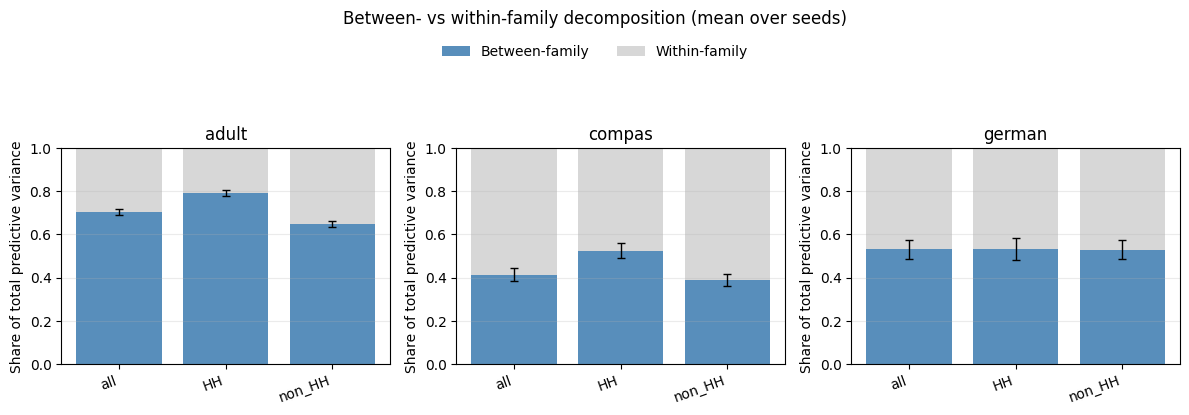

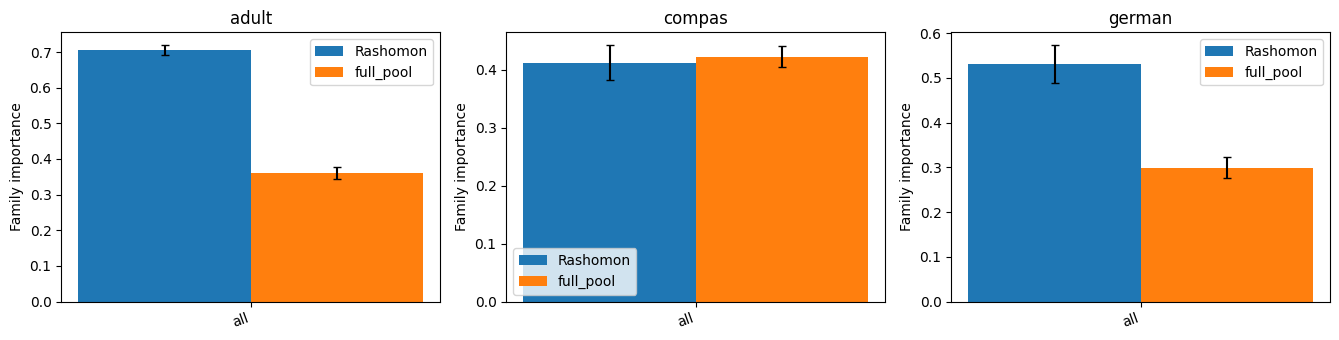

In [7]:
if not df_fam_agg.empty:
    fam_rash = df_fam_agg[df_fam_agg["pool_type"] == POOL_TYPE_RASHOMON].copy()
    plot_family_importance_bars(
        fam_rash,
        fig_path=FIG_DIR / "family_importance_agg_rashomon.pdf",
    )
else:
    print("No family-importance rows.")

if not df_fam_agg.empty and "pool_type" in df_fam_agg.columns:
    plot_family_importance_compare_bars(
        df_fam_agg[df_fam_agg["subset"] == "all"].copy(),
        fig_path=FIG_DIR / "family_importance_compare_all.pdf",
    )


## Within-family hyperparameter drivers (V_m-based, updated grouping)

**Grouping strategy:** 
- Categorical HPs → exact groups
- Numeric HPs with ≤4 unique values → exact groups  
- Numeric HPs with >4 unique values → tertiles (low/medium/high)
- Groups with <2 models are merged or skipped
- Grouping decided per (dataset, family, HP) across all seeds
- Importance computed per seed; aggregated mean/std only over valid seeds
- Exported tables include `grouping_type`, `n_groups`, `min_group_size`, `n_seeds`

## Hotspot-specific hyperparameter drivers (HH-vs-all delta)


**Interpretation:** Positive delta → HP is more important for hotspot predictions; negative delta → HP is more important for non-hotspot predictions.

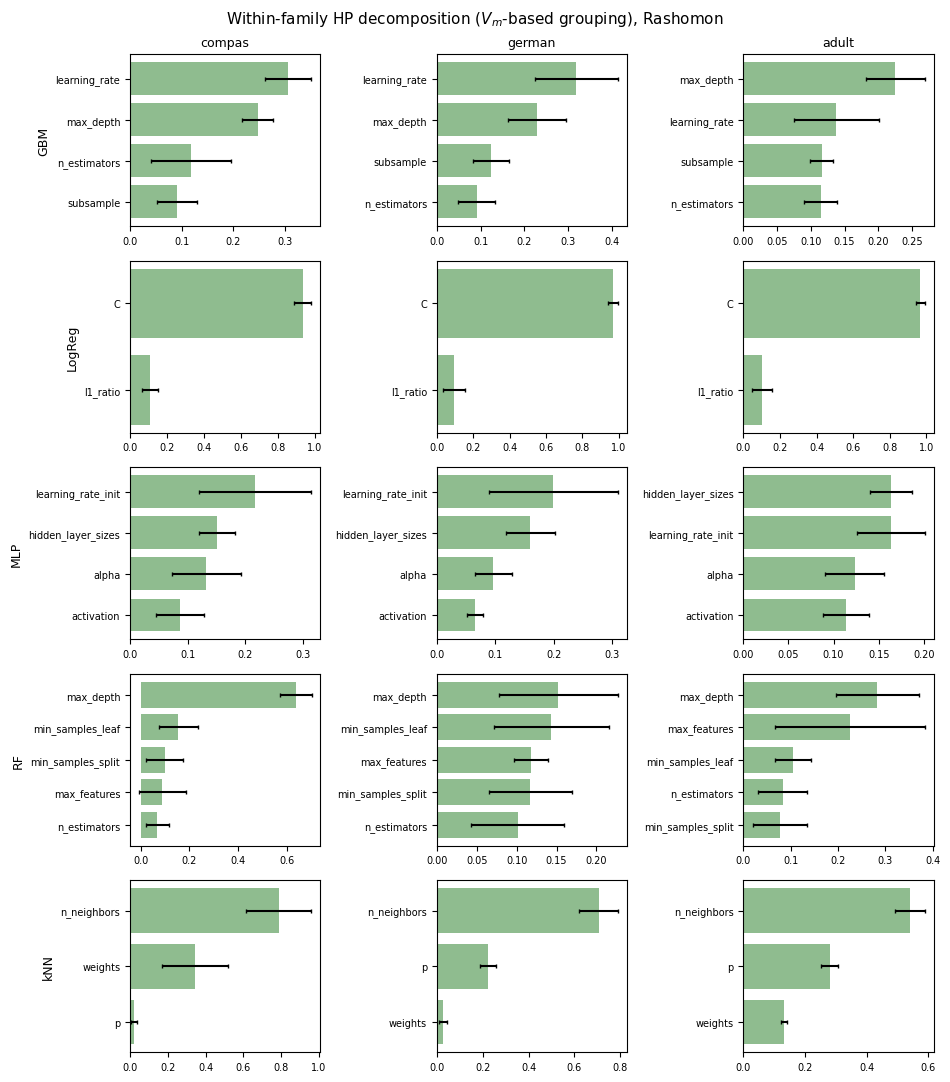

In [8]:
# Secondary decomposition: save only one Rashomon overview grid
decomp_all = pd.DataFrame()

if not df_decomp_agg.empty:
    decomp_all = df_decomp_agg[df_decomp_agg["subset"] == "all"].copy()
    if "pool_type" in decomp_all.columns:
        decomp_all = decomp_all[decomp_all["pool_type"] == POOL_TYPE_RASHOMON]

if not decomp_all.empty:
    plot_decomp_hp_grid_rashomon(
        decomp_all,
        datasets=DATASETS,
        families=["GBM", "LogReg", "MLP", "RF", "kNN"],
        subset="all",
        top_n=min(TOP_HP, 8),
        fig_path=FIG_DIR / "decomp_hp_secondary_bar_rashomon_grid.pdf",
        show=True,
    )
else:
    print("No decomposition HP aggregates for secondary bar charts.")

## Within-family HP decomposition figure

This grid visualizes decomposition-based within-family hyperparameter importance within the Rashomon set. It is the source for the thesis figure on within-family hyperparameter drivers.

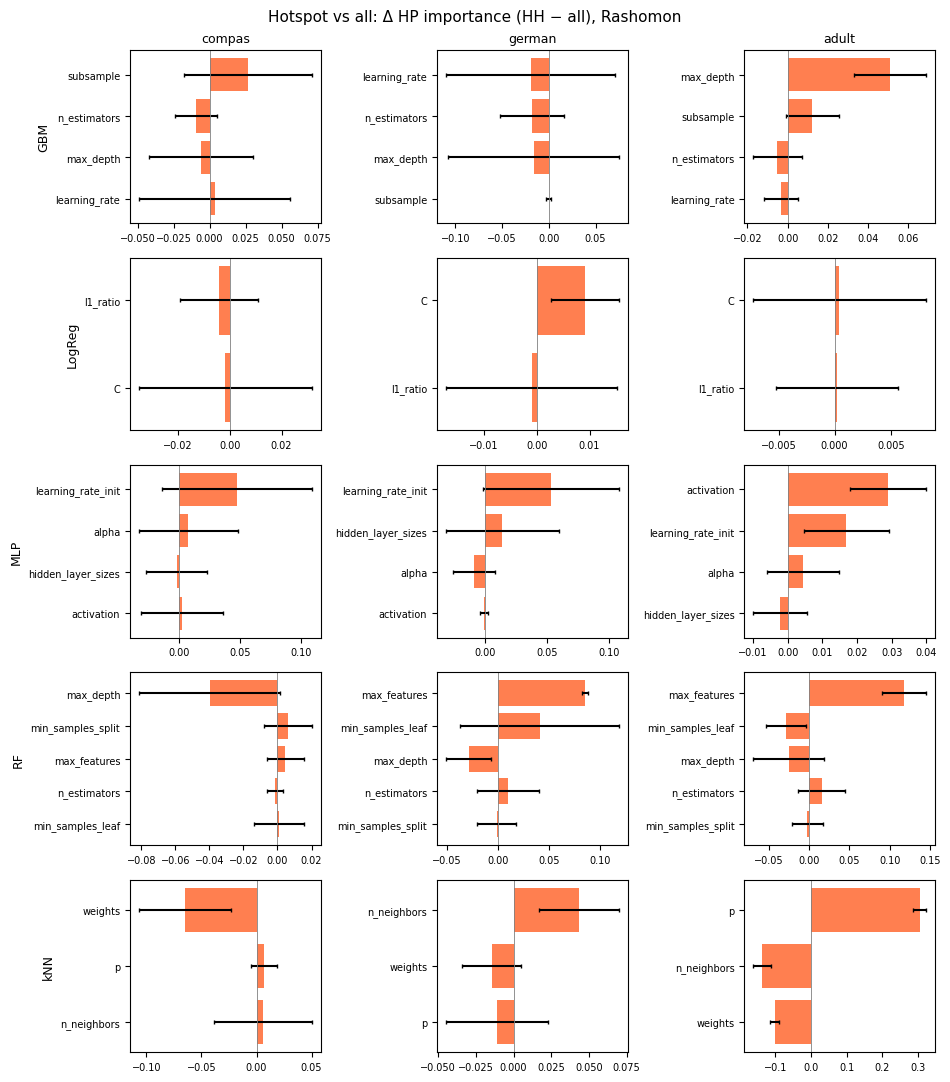

In [9]:
# Hotspot deltas: save only one overview grid
_ddel = df_delta_agg.copy()

if not _ddel.empty and "pool_type" in _ddel.columns:
    _ddel = _ddel[_ddel["pool_type"] == POOL_TYPE_RASHOMON]

if not _ddel.empty:
    plot_hotspot_hp_delta_grid(
        _ddel,
        datasets=DATASETS,
        families=["GBM", "LogReg", "MLP", "RF", "kNN"],
        top_n=min(TOP_HP, 8),
        fig_path=FIG_DIR / "decomp_hp_hotspot_delta_grid.pdf",
        show=True,
    )
else:
    print("No hotspot deltas (need HH subset with enough points per seed).")

## Compact exports

The notebook writes compact thesis-facing CSVs only:

- family-importance aggregates
- combined within-family HP aggregate tables
- combined hotspot-delta aggregate table
- compact COMPAS hotspot-delta summary
- compact meta-model summary files generated by the meta-model pipeline

---

## PRIMARY ANALYSIS COMPLETE

The thesis-facing Section 5.7 outputs are complete above: family importance, within-family HP decomposition, hotspot-specific HP shifts, and compact summary exports.

---